<a href="https://colab.research.google.com/github/objectrom/Movie-Genre-Classification/blob/main/movie_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import zipfile
import pandas as pd

drive.mount('/content/drive')

# Drive 내 파일 경로로 직접 접근
with zipfile.ZipFile('/content/drive/MyDrive/DATA 198/Spring-2026-Data-198-Decal-Project.zip', 'r') as z:
    z.extract('Main.ipynb', '/content/')
    z.extract('movies_metadata.csv', '/content/')

movies = pd.read_csv('/content/movies_metadata.csv')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

import torch
import torch.nn as nn
from sklearn.preprocessing import MultiLabelBinarizer
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

In [ ]:
movies = pd.read_csv("/content/movies_metadata.csv")

In [ ]:
movies["genres_list"] = movies["genres"].apply(
    lambda x: re.findall(r"'name':\s*'([^']+)'", x)
)

movies["languages_list"] = movies["spoken_languages"].str.findall(r"'name':\s*'([^']+)'")
movies["production_companies_list"] = movies["production_companies"].str.findall(r"'name':\s*'([^']+)'")
movies["production_countries_list"] = movies["production_countries"].str.findall(r"'name':\s*'([^']+)'")
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")

In [ ]:
movies.drop(columns=['belongs_to_collection', 'homepage', 'title', 'status', 'video', 'genres', 'spoken_languages', 'production_companies', 'production_countries', 'poster_path'], inplace=True)

In [ ]:
VALID_GENRES = {
    'Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
    'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
    'TV Movie', 'Thriller', 'War', 'Western', 'Foreign'
}
movies["genres_list"] = movies["genres_list"].apply(
    lambda lst: [g for g in lst if g in VALID_GENRES]
)
movies = movies[movies["genres_list"].apply(len) > 0]

In [ ]:
movies = movies[movies['overview'].isna() == False]
movies.shape

(42324, 18)

In [ ]:
movies['overview'].isna().value_counts()

,count
overview,
False,42324


In [ ]:
np.sum(movies['original_title'].isna())

np.int64(0)

In [ ]:
mlb = MultiLabelBinarizer()

genre_ohe = pd.DataFrame(
    mlb.fit_transform(movies["genres_list"]),
    columns=mlb.classes_,
    index=movies.index
)

movies = pd.concat([movies, genre_ohe], axis=1)

In [ ]:
movies.columns

Index(['adult', 'budget', 'id', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'release_date', 'revenue',
       'runtime', 'tagline', 'vote_average', 'vote_count', 'genres_list',
       'languages_list', 'production_companies_list',
       'production_countries_list', 'Action', 'Adventure', 'Animation',
       'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy',
       'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance',
       'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western'],
      dtype='object')

In [ ]:
movies.head()

,adult,budget,id,imdb_id,original_language,original_title,overview,popularity,release_date,revenue,...,History,Horror,Music,Mystery,Romance,Science Fiction,TV Movie,Thriller,War,Western
0,False,30000000,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,1995-10-30,373554033.0,...,0,0,0,0,0,0,0,0,0,0
1,False,65000000,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,1995-12-15,262797249.0,...,0,0,0,0,0,0,0,0,0,0
2,False,0,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,1995-12-22,0.0,...,0,0,0,0,1,0,0,0,0,0
3,False,16000000,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,1995-12-22,81452156.0,...,0,0,0,0,1,0,0,0,0,0
4,False,0,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,1995-02-10,76578911.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=device)

# Encode overviews on the selected device
embeddings = model.encode(
    movies['overview'].tolist(),
    show_progress_bar=True,
    device=device  # ensure encoding runs on the chosen device
)

# Convert embeddings to a NumPy array (already default), and show shape as a quick sanity check
embeddings = np.asarray(embeddings)
print('Embeddings shape:', embeddings.shape)

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1323 [00:00<?, ?it/s]

Embeddings shape: (42324, 768)


In [ ]:
model = SentenceTransformer('intfloat/e5-large-v2', device=device)

texts = ["passage: " + t for t in movies['overview'].tolist()]

embeddings = model.encode(
    texts,
    show_progress_bar=True,
    device=device
)

embeddings = np.asarray(embeddings)
print('Embeddings shape:', embeddings.shape)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/1323 [00:00<?, ?it/s]

Embeddings shape: (42324, 1024)


In [ ]:
movies['log_revenue'] = np.log(movies['revenue'].fillna(0).astype(int) + 1)
movies['log_budget'] = np.log(movies['budget'].fillna(0).astype(int) + 1)

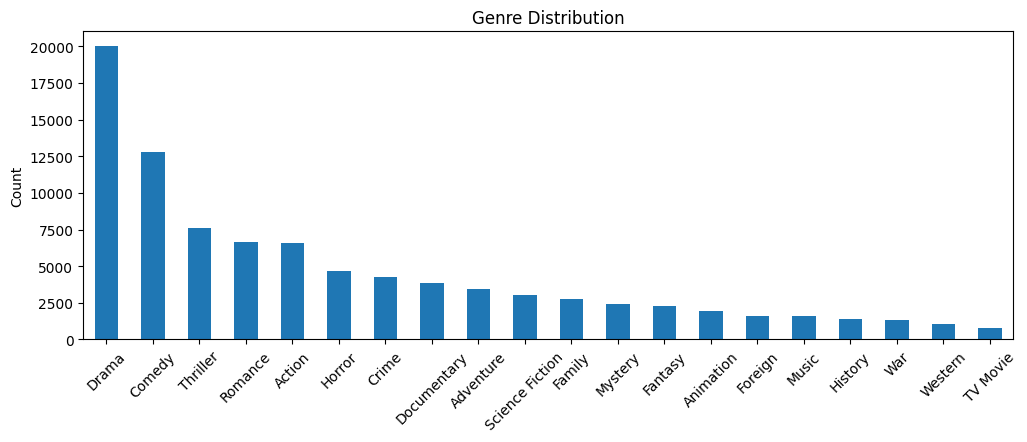

In [ ]:
genre_cols = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign',
              'History', 'Horror', 'Music', 'Mystery', 'Romance',
              'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

movies[genre_cols].sum().sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.title('Genre Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

[Cutoff = 2000] Genres kept   : ['Action', 'Adventure', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']
[Cutoff = 2000] Genres dropped: ['Animation', 'Foreign', 'History', 'Music', 'TV Movie', 'War', 'Western']
Total movies : 42,324
Year range   : 1874.0 – 2020.0

Genre distribution:
Drama              20023
Comedy             12806
Thriller            7586
Romance             6673
Action              6565
Horror              4660
Crime               4269
Documentary         3886
Adventure           3470
Science Fiction     3028
Family              2732
Mystery             2451
Fantasy             2290
dtype: int64


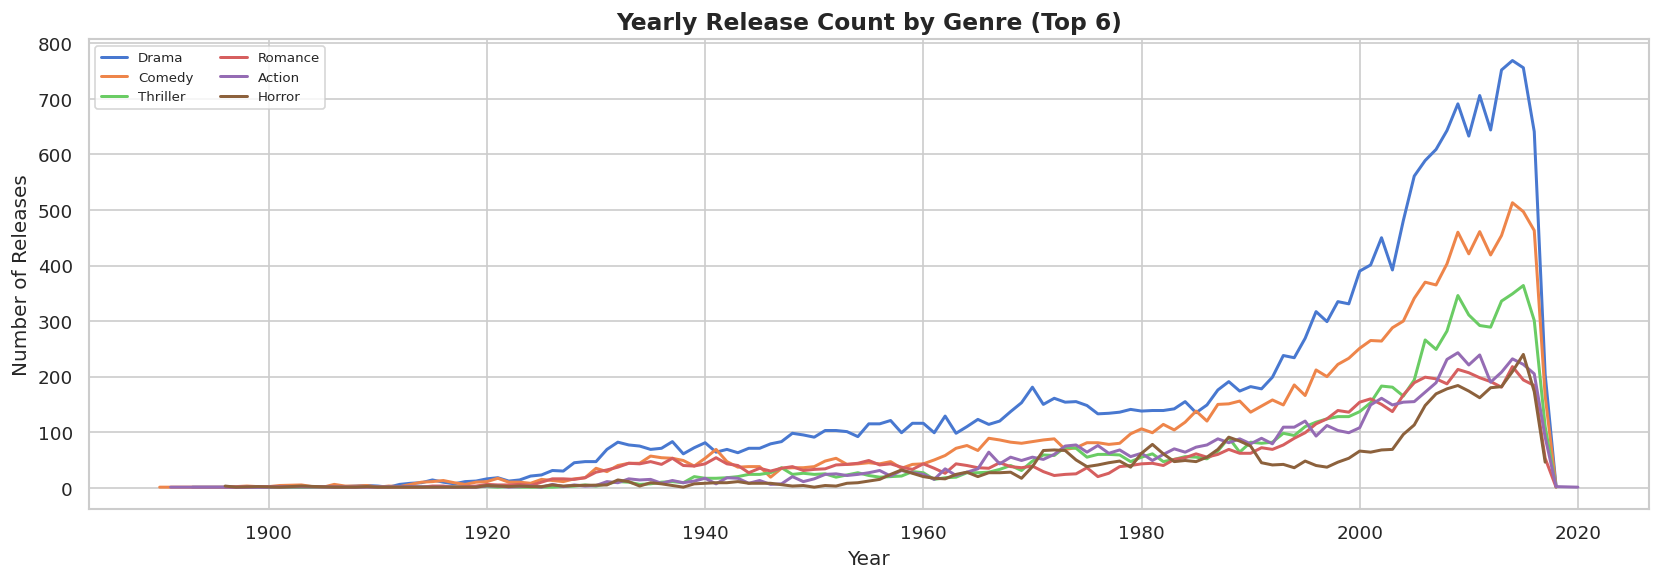

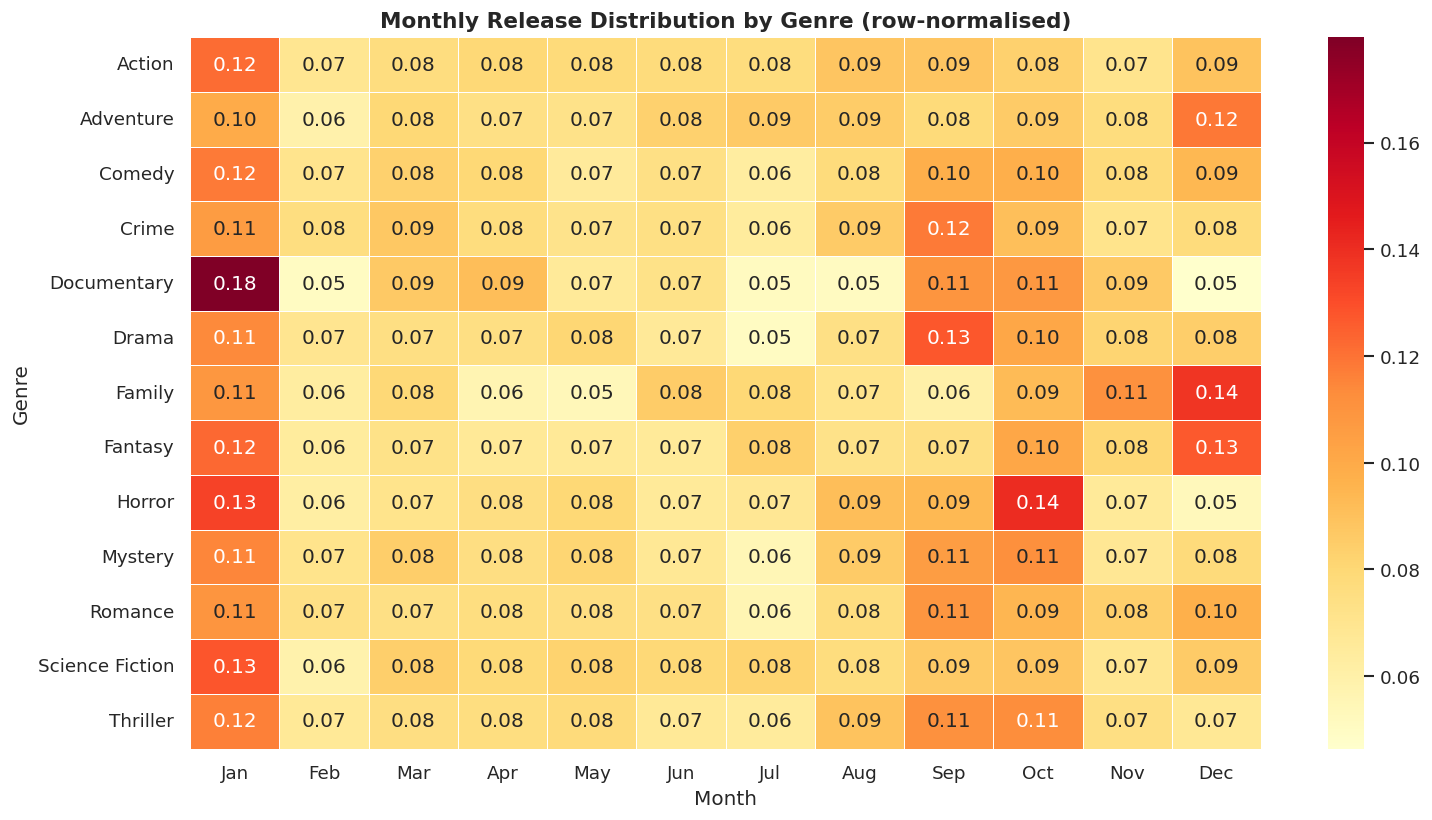

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

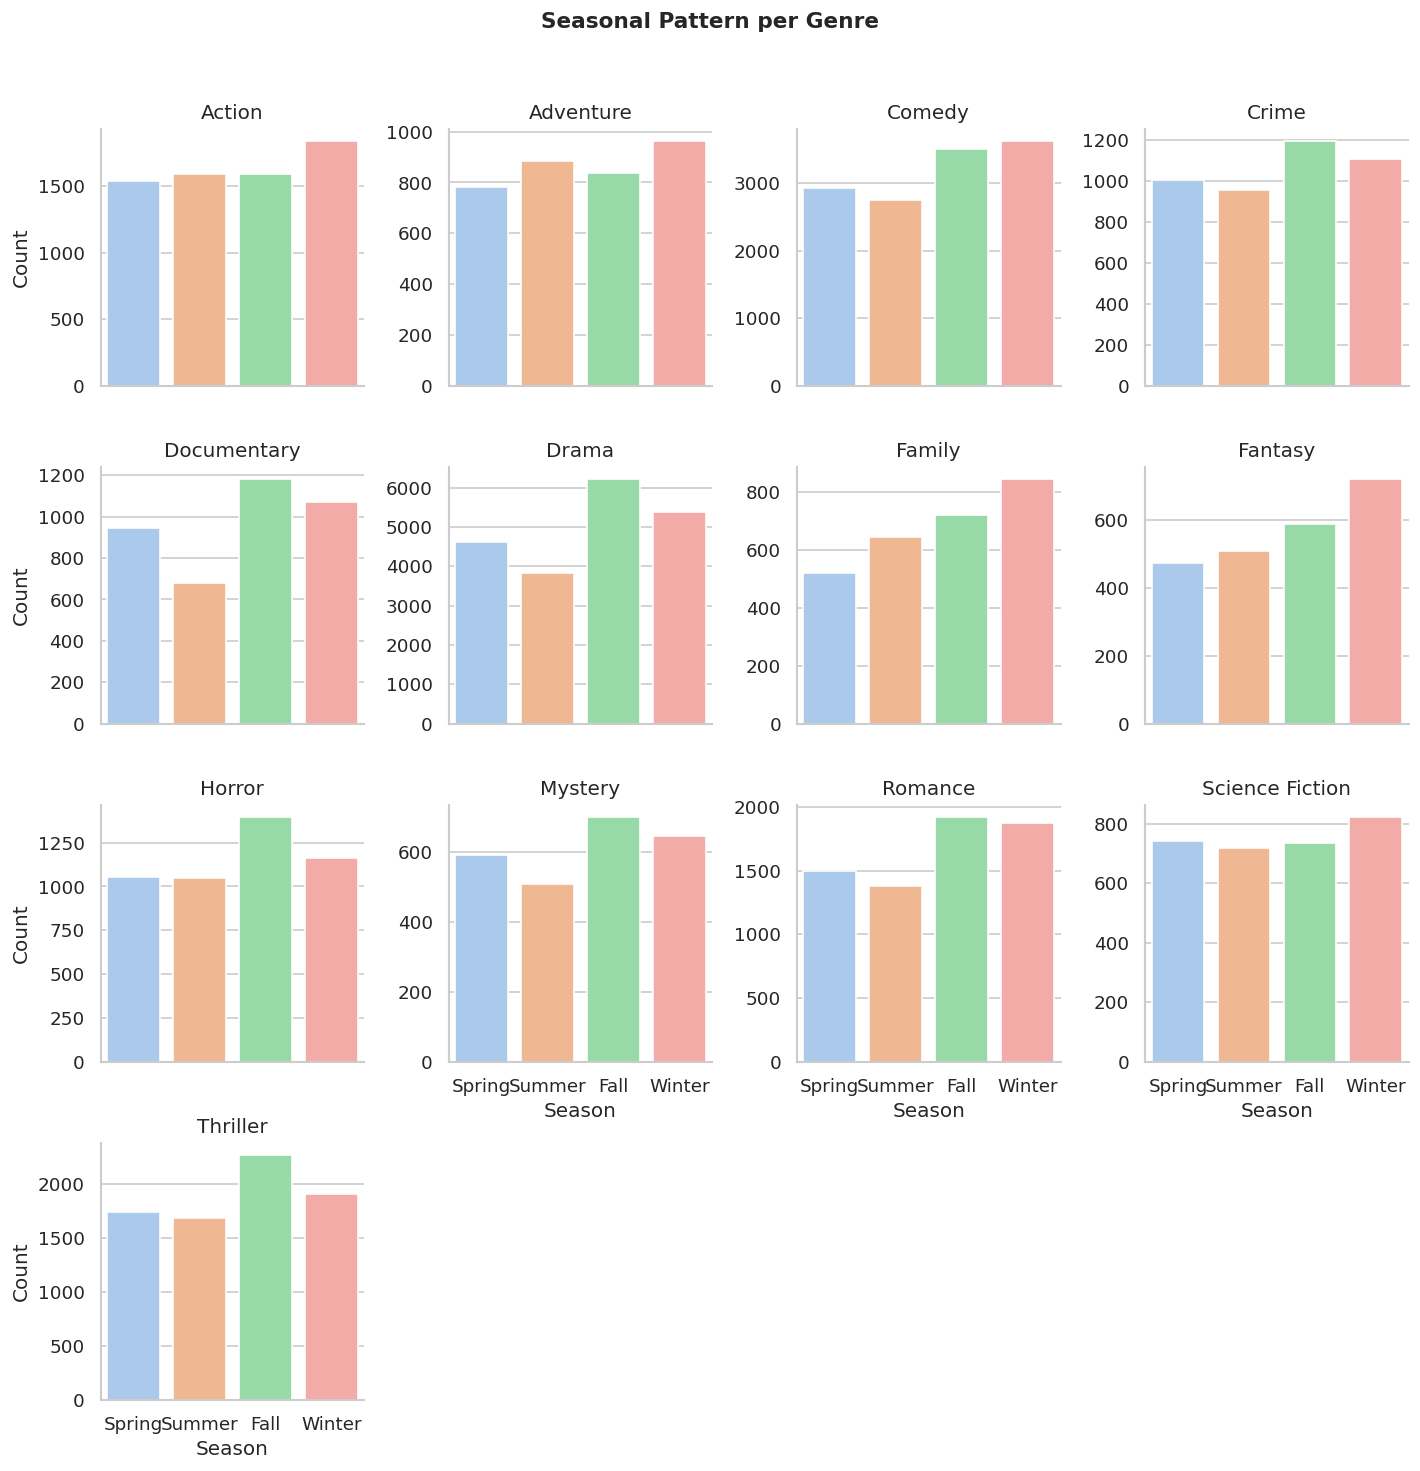

/tmp/ipykernel_1079/2875531977.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=concentration, x="HHI", y="genre",


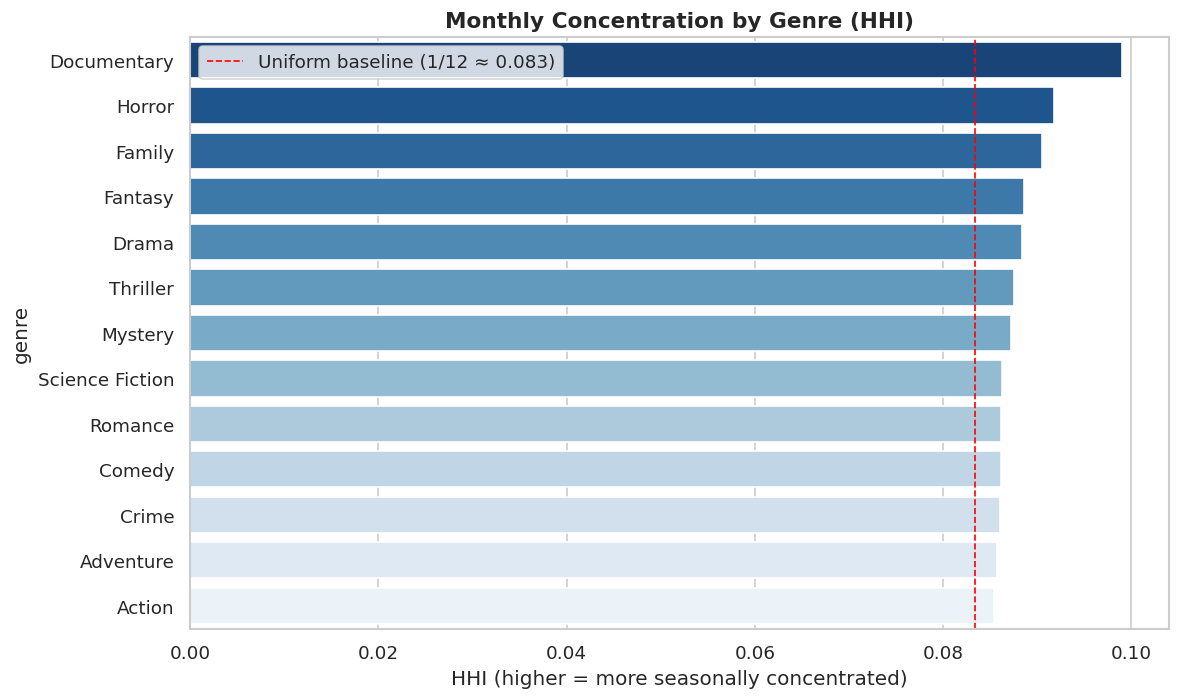

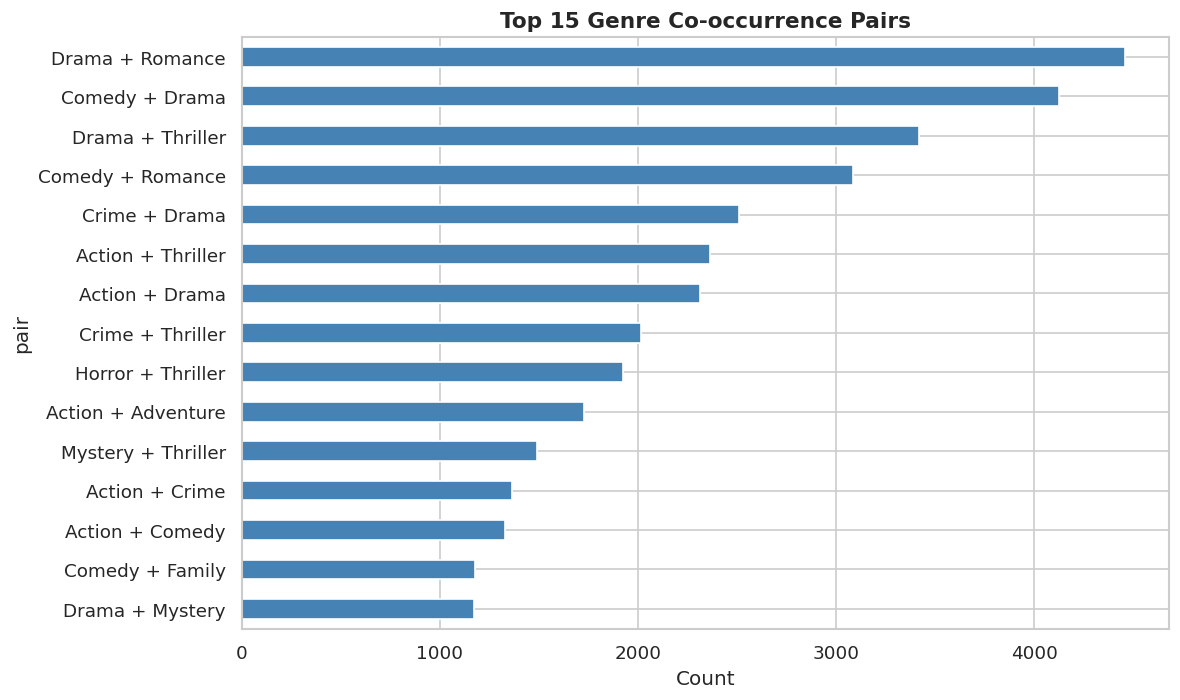

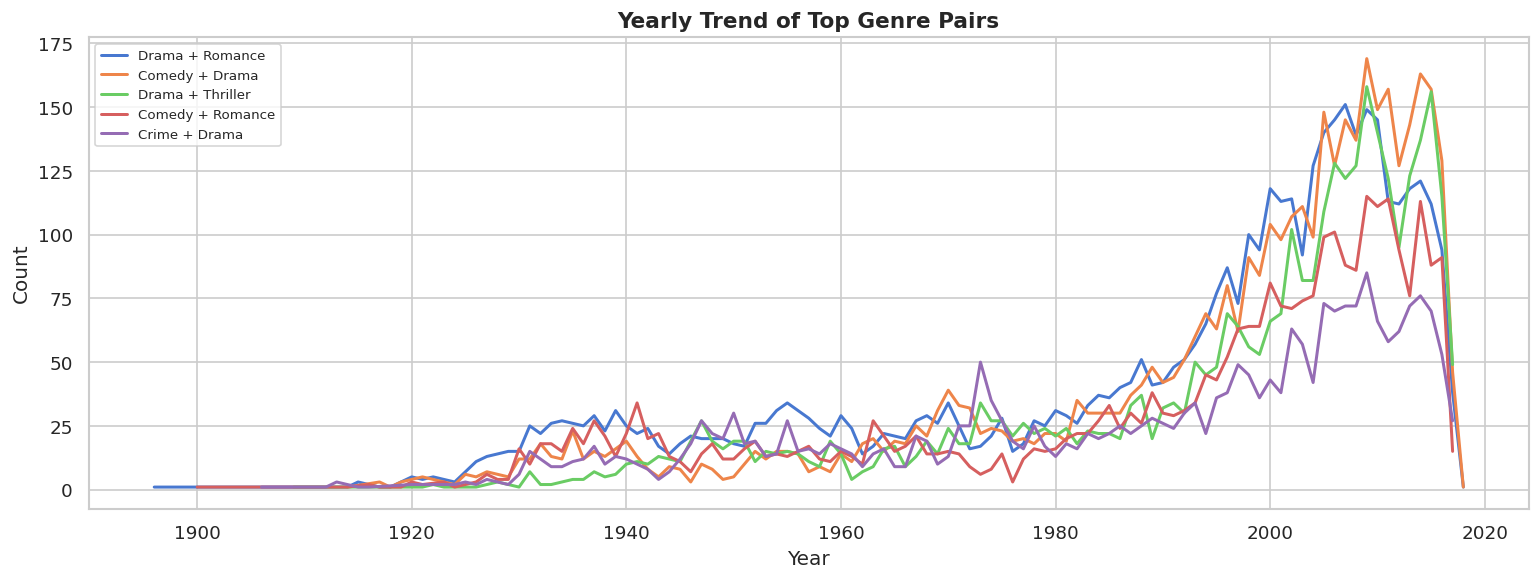

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be remo

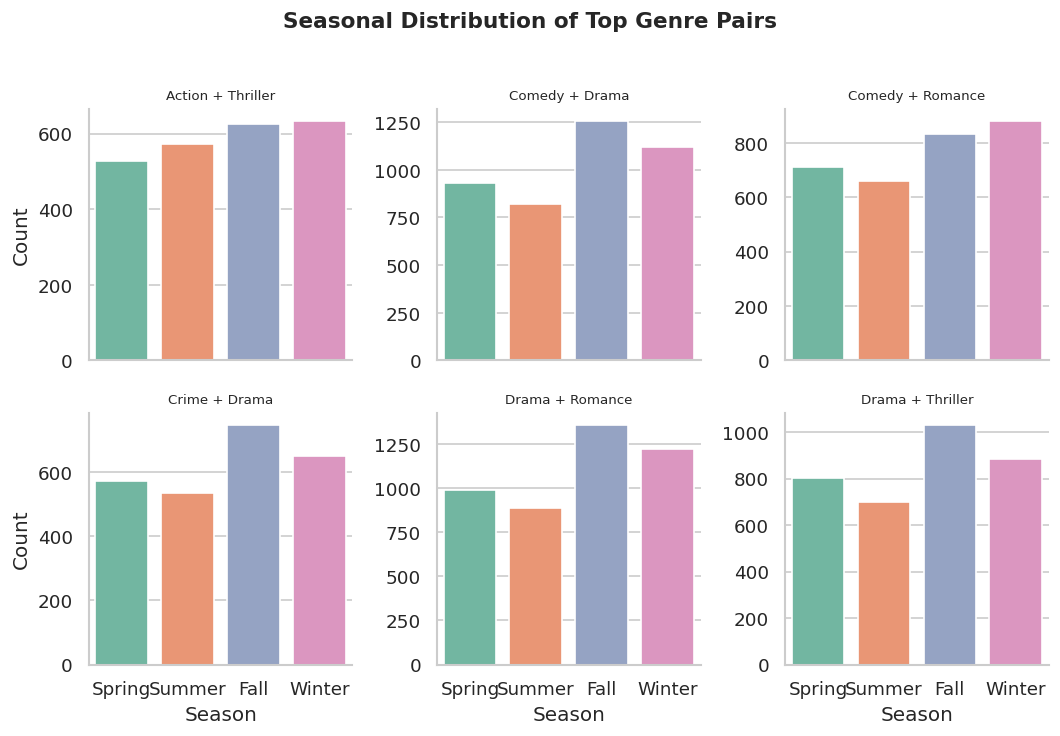


✅ EDA complete. Figures saved as 01~07 PNG files.


In [ ]:
"""
EDA: Release Date × Genre Analysis
====================================
Assumptions:
  - movies['release_date'] : str, format "YYYY-MM-DD"  (e.g. "1995-10-30")
  - Genre columns          : binary one-hot (0/1) for each genre below
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# ── Style ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# =============================================================================
# 0. GENRE COLUMNS  (cutoff: genres with ≤ 2000 samples removed)
# =============================================================================
genre_cols = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
              'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign',
              'History', 'Horror', 'Music', 'Mystery', 'Romance',
              'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']

CUTOFF = 2000
genre_counts_raw = movies[genre_cols].sum()
genre_cols = genre_counts_raw[genre_counts_raw > CUTOFF].index.tolist()

print(f"[Cutoff = {CUTOFF}] Genres kept   : {genre_cols}")
print(f"[Cutoff = {CUTOFF}] Genres dropped: {genre_counts_raw[genre_counts_raw <= CUTOFF].index.tolist()}")

# =============================================================================
# 1. PREPROCESSING
# =============================================================================
movies["release_date"] = pd.to_datetime(movies["release_date"], format="%Y-%m-%d")
movies["year"]    = movies["release_date"].dt.year
movies["month"]   = movies["release_date"].dt.month
movies["quarter"] = movies["release_date"].dt.quarter
movies["season"]  = movies["month"].map({
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Spring",  4:"Spring", 5:"Spring",
    6:"Summer",  7:"Summer", 8:"Summer",
    9:"Fall",   10:"Fall",  11:"Fall"
})

# ── Long format: one row per (movie, genre) pair ───────────────────────────
meta_cols = ["release_date", "year", "month", "quarter", "season"]
long = (movies[meta_cols + genre_cols]
        .melt(id_vars=meta_cols, value_vars=genre_cols,
              var_name="genre", value_name="flag")
        .query("flag == 1")
        .drop(columns="flag")
        .reset_index(drop=True))

print(f"Total movies : {len(movies):,}")
print(f"Year range   : {movies['year'].min()} – {movies['year'].max()}")
print(f"\nGenre distribution:")
print(movies[genre_cols].sum().sort_values(ascending=False))

# =============================================================================
# 2. YEARLY TREND BY GENRE
# =============================================================================
yearly = (long.groupby(["year", "genre"])
              .size()
              .reset_index(name="count"))

fig, ax = plt.subplots(figsize=(14, 5))
top6 = movies[genre_cols].sum().sort_values(ascending=False).head(6).index.tolist()
for genre in top6:
    sub = yearly[yearly["genre"] == genre]
    ax.plot(sub["year"], sub["count"], label=genre, linewidth=1.8)

ax.set_title("Yearly Release Count by Genre (Top 6)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Number of Releases")
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("01_yearly_trend.png"); plt.show()

# =============================================================================
# 3. MONTHLY / SEASONAL PATTERN BY GENRE
# =============================================================================
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# 3-A. Heatmap: genre × month (normalised within each genre)
monthly_pivot = (long.groupby(["genre", "month"])
                     .size()
                     .unstack(fill_value=0))
monthly_norm  = monthly_pivot.div(monthly_pivot.sum(axis=1), axis=0)
monthly_norm.columns = MONTH_LABELS

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(monthly_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.4, ax=ax)
ax.set_title("Monthly Release Distribution by Genre (row-normalised)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Month"); ax.set_ylabel("Genre")
plt.tight_layout()
plt.savefig("02_monthly_heatmap.png"); plt.show()

# 3-B. Seasonal bar chart per genre
SEASON_ORDER = ["Spring", "Summer", "Fall", "Winter"]
seasonal = (long.groupby(["season", "genre"])
                .size()
                .reset_index(name="count"))

g = sns.FacetGrid(seasonal, col="genre", col_wrap=4, height=3, sharey=False)
g.map_dataframe(sns.barplot, x="season", y="count",
                order=SEASON_ORDER, palette="pastel")
g.set_titles("{col_name}"); g.set_axis_labels("Season", "Count")
g.figure.suptitle("Seasonal Pattern per Genre", y=1.02,
                  fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("03_seasonal_facet.png"); plt.show()

# =============================================================================
# 4. CONCENTRATION INDEX  (HHI on monthly share)
#    higher HHI → more seasonally concentrated
# =============================================================================
def hhi(series):
    shares = series / series.sum()
    return (shares ** 2).sum()

concentration = (long.groupby(["genre", "month"])
                     .size()
                     .groupby(level="genre")
                     .apply(hhi)
                     .sort_values(ascending=False)
                     .reset_index(name="HHI"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=concentration, x="HHI", y="genre",
            palette="Blues_r", ax=ax)
ax.axvline(1/12, color="red", linestyle="--", linewidth=1,
           label="Uniform baseline (1/12 ≈ 0.083)")
ax.set_title("Monthly Concentration by Genre (HHI)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("HHI (higher = more seasonally concentrated)")
ax.legend()
plt.tight_layout()
plt.savefig("04_concentration_hhi.png"); plt.show()

# =============================================================================
# 5. GENRE COMBINATION × DATE
# =============================================================================
def get_pairs(row):
    active = [g for g in genre_cols if row[g] == 1]
    return list(combinations(sorted(active), 2))

pair_rows = []
for _, row in movies.iterrows():
    for pair in get_pairs(row):
        pair_rows.append({"pair": f"{pair[0]} + {pair[1]}",
                          "year": row["year"],
                          "season": row["season"]})

pair_df = pd.DataFrame(pair_rows)
top_pairs = pair_df["pair"].value_counts().head(10).index.tolist()

# 5-A. Overall top-15 pairs
fig, ax = plt.subplots(figsize=(10, 6))
pair_df["pair"].value_counts().head(15).plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_title("Top 15 Genre Co-occurrence Pairs", fontsize=13, fontweight="bold")
ax.set_xlabel("Count")
plt.tight_layout()
plt.savefig("05_top_pairs.png"); plt.show()

# 5-B. Yearly trend of top-5 pairs
pair_yearly = (pair_df[pair_df["pair"].isin(top_pairs[:5])]
               .groupby(["year", "pair"])
               .size()
               .reset_index(name="count"))

fig, ax = plt.subplots(figsize=(13, 5))
for pair in top_pairs[:5]:
    sub = pair_yearly[pair_yearly["pair"] == pair]
    ax.plot(sub["year"], sub["count"], label=pair, linewidth=1.8)
ax.set_title("Yearly Trend of Top Genre Pairs", fontsize=13, fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Count")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("06_pair_yearly_trend.png"); plt.show()

# 5-C. Seasonal distribution of top-6 pairs
pair_season = (pair_df[pair_df["pair"].isin(top_pairs[:6])]
               .groupby(["season", "pair"])
               .size()
               .reset_index(name="count"))

g2 = sns.FacetGrid(pair_season, col="pair", col_wrap=3, height=3, sharey=False)
g2.map_dataframe(sns.barplot, x="season", y="count",
                 order=SEASON_ORDER, palette="Set2")
g2.set_titles("{col_name}", size=8)
g2.set_axis_labels("Season", "Count")
g2.figure.suptitle("Seasonal Distribution of Top Genre Pairs",
                   y=1.02, fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("07_pair_seasonal.png"); plt.show()

print("\n✅ EDA complete. Figures saved as 01~07 PNG files.")

In [ ]:
movies[genre_cols].sum()

,0
Action,6565
Adventure,3470
Animation,1920
Comedy,12806
Crime,4269
Documentary,3886
Drama,20023
Family,2732
Fantasy,2290
Foreign,1599


**Baseline (Without doing anything)**

In [ ]:
# ── Baseline ──────────────────────────────────────────────
X = embeddings
y = genre_ohe.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_base = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)
y_probs_base = model_base.predict_proba(X_test)
y_pred_base_t = (y_probs_base >= 0.25).astype(int)

results = {
    'Baseline': {
        'micro': f1_score(y_test, y_pred_base_t, average='micro'),
        'macro': f1_score(y_test, y_pred_base_t, average='macro'),
        'weighted': f1_score(y_test, y_pred_base_t, average='weighted'),
        'per_genre': f1_score(y_test, y_pred_base_t, average=None)
    }
}
print("Baseline completed")
print(f"Micro: {results['Baseline']['micro']:.4f} | Macro: {results['Baseline']['macro']:.4f}")

Baseline completed
Micro: 0.6290 | Macro: 0.5297


**Baseline(log revenue + log budget)**

In [ ]:
# ── Baseline + log revenue + log budget ──────────────────────────────────────────────
X = np.hstack([
    embeddings,
    movies['log_budget'].values.reshape(-1, 1),  # (n,) → (n, 1)
    movies['log_revenue'].values.reshape(-1, 1)
])
y = genre_ohe.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_base = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)
y_probs_base = model_base.predict_proba(X_test)
y_pred_base_t = (y_probs_base >= 0.25).astype(int)

results = {
    'Baseline': {
        'micro': f1_score(y_test, y_pred_base_t, average='micro'),
        'macro': f1_score(y_test, y_pred_base_t, average='macro'),
        'weighted': f1_score(y_test, y_pred_base_t, average='weighted'),
        'per_genre': f1_score(y_test, y_pred_base_t, average=None)
    }
}
print("Baseline completed")
print(f"Micro: {results['Baseline']['micro']:.4f} | Macro: {results['Baseline']['macro']:.4f}")

Baseline completed
Micro: 0.5870 | Macro: 0.4853


**Solution1 - Cutting off with Genres less than 2000**

In [ ]:
# ── Experiment 1: Genre Cutoff ─────────────────────────────
genre_cols = mlb.classes_

# Only genres over 2000 will remain
valid_mask = movies[genre_cols].sum() > 3000
valid_genres = genre_cols[valid_mask]
print(f"({len(valid_genres)} genres remain): {list(valid_genres)}")

# new dataframe
genre_ohe_cut = genre_ohe[valid_genres]
movies_cut = movies.copy()

# Movies that have at least one genres will be used
has_genre = genre_ohe_cut.sum(axis=1) > 0
X_cut = embeddings[has_genre]
y_cut = genre_ohe_cut[has_genre].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

model_cut = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model_cut.fit(X_train_c, y_train_c)

y_probs_cut = model_cut.predict_proba(X_test_c)
y_pred_cut = (y_probs_cut >= 0.25).astype(int)

results['Cutoff'] = {
    'micro': f1_score(y_test_c, y_pred_cut, average='micro'),
    'macro': f1_score(y_test_c, y_pred_cut, average='macro'),
    'weighted': f1_score(y_test_c, y_pred_cut, average='weighted'),
    'per_genre': f1_score(y_test_c, y_pred_cut, average=None)
}
print("Cutoff Complete")
print(f"Micro: {results['Cutoff']['micro']:.4f} | Macro: {results['Cutoff']['macro']:.4f}")

(10 genres remain): ['Action', 'Adventure', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Horror', 'Romance', 'Science Fiction', 'Thriller']
Cutoff Complete
Micro: 0.6655 | Macro: 0.6440


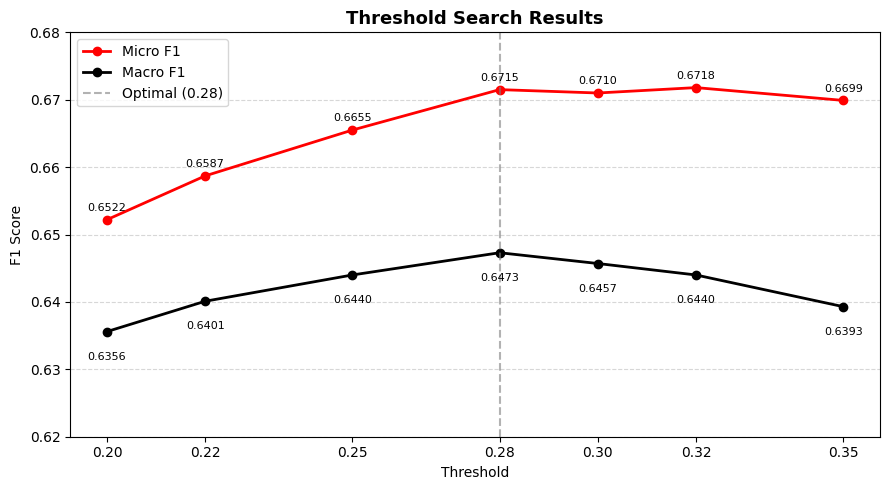

In [ ]:
# ── Experiment 3: Threshold Search Visualization ─────────────────────────────
import matplotlib.pyplot as plt

thresholds = [0.20, 0.22, 0.25, 0.28, 0.30, 0.32, 0.35]
micro_scores = [0.6522, 0.6587, 0.6655, 0.6715, 0.6710, 0.6718, 0.6699]
macro_scores = [0.6356, 0.6401, 0.6440, 0.6473, 0.6457, 0.6440, 0.6393]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(thresholds, micro_scores, marker='o', label='Micro F1', color='red', linewidth=2)
ax.plot(thresholds, macro_scores, marker='o', label='Macro F1', color='black', linewidth=2)

# Best threshold
ax.axvline(x=0.28, color='gray', linestyle='--', alpha=0.6, label='Optimal (0.28)')

for t, mi, ma in zip(thresholds, micro_scores, macro_scores):
    ax.text(t, mi + 0.001, f'{mi:.4f}', ha='center', va='bottom', fontsize=8, color='black')
    ax.text(t, ma - 0.003, f'{ma:.4f}', ha='center', va='top', fontsize=8, color='black')

ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Search Results', fontsize=13, fontweight='bold')
ax.set_xticks(thresholds)
ax.set_ylim(0.62, 0.68)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

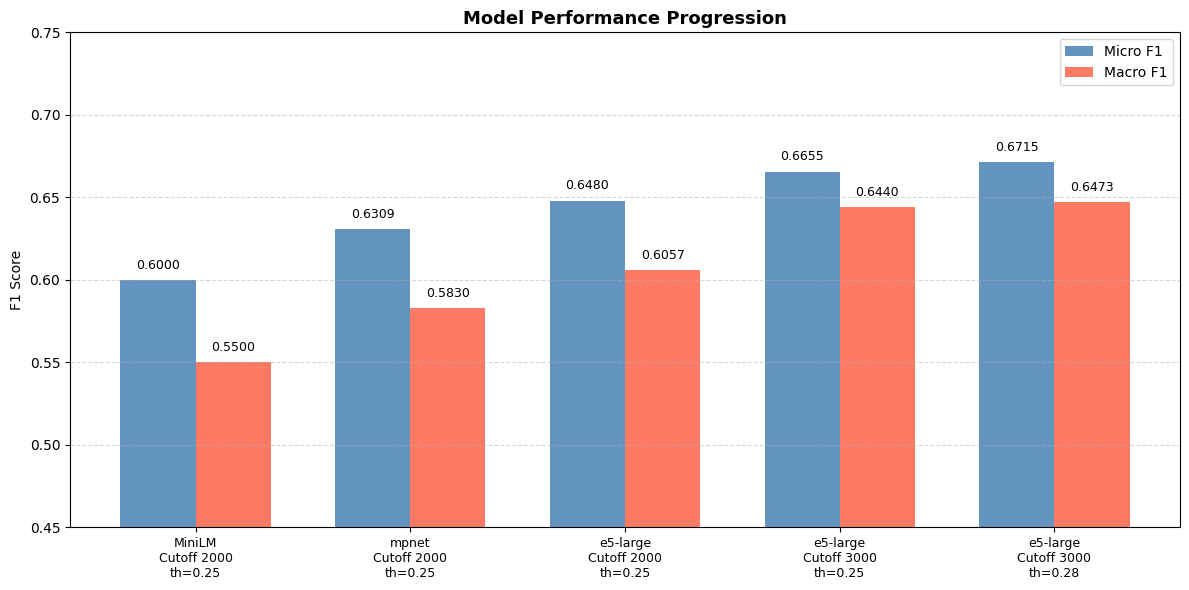

**Cutoff + log revenue + log budget**

In [ ]:
# ── Experiment 1: Genre Cutoff + log revenue + log budget ─────────────────────────────
genre_cols = mlb.classes_

# Only genres over 2000 will remain
valid_mask = movies[genre_cols].sum() > 2000
valid_genres = genre_cols[valid_mask]
print(f"({len(valid_genres)} genres remain): {list(valid_genres)}")

# new dataframe
genre_ohe_cut = genre_ohe[valid_genres]
movies_cut = movies.copy()

# Movies that have at least one genres will be used
has_genre = genre_ohe_cut.sum(axis=1) > 0
X_cut = np.hstack([
    embeddings[has_genre],
    movies.loc[has_genre.values, 'log_budget'].values.reshape(-1, 1),
    movies.loc[has_genre.values, 'log_revenue'].values.reshape(-1, 1)
])
y_cut = genre_ohe_cut[has_genre].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

model_cut = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model_cut.fit(X_train_c, y_train_c)

y_probs_cut = model_cut.predict_proba(X_test_c)
y_pred_cut = (y_probs_cut >= 0.25).astype(int)

results['Cutoff'] = {
    'micro': f1_score(y_test_c, y_pred_cut, average='micro'),
    'macro': f1_score(y_test_c, y_pred_cut, average='macro'),
    'weighted': f1_score(y_test_c, y_pred_cut, average='weighted'),
    'per_genre': f1_score(y_test_c, y_pred_cut, average=None)
}
print("Cutoff Complete")
print(f"Micro: {results['Cutoff']['micro']:.4f} | Macro: {results['Cutoff']['macro']:.4f}")

(13 genres remain): ['Action', 'Adventure', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']
Cutoff Complete
Micro: 0.6058 | Macro: 0.5535


In [ ]:
movies_cut[valid_genres].sum()

,0
Action,6565
Adventure,3470
Comedy,12806
Crime,4269
Documentary,3886
Drama,20023
Family,2732
Fantasy,2290
Horror,4660
Mystery,2451


**Solution2 - Weight Rebalancing(More penalty, More bonus)**

In [ ]:
# ── Experiment 2: Weight Rebalancing ──────────────────────
X_w = embeddings
y_w = genre_ohe.values

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_w, y_w, test_size=0.2, random_state=42
)

model_weight = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced')
)
model_weight.fit(X_train_w, y_train_w)

y_probs_w = model_weight.predict_proba(X_test_w)
y_pred_w = (y_probs_w >= 0.25).astype(int)

results['Rebalancing'] = {
    'micro': f1_score(y_test_w, y_pred_w, average='micro'),
    'macro': f1_score(y_test_w, y_pred_w, average='macro'),
    'weighted': f1_score(y_test_w, y_pred_w, average='weighted'),
    'per_genre': f1_score(y_test_w, y_pred_w, average=None)
}
print("Rebalancing Complete")
print(f"Micro: {results['Rebalancing']['micro']:.4f} | Macro: {results['Rebalancing']['macro']:.4f}")

Rebalancing Complete
Micro: 0.3499 | Macro: 0.3056


**Solution3 - cutoff + Rebalancing**

In [ ]:
# ── Experiment 3: Cutoff + Rebalancing ────────────────────
X_both = embeddings[has_genre]
y_both = genre_ohe_cut[has_genre].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_both, y_both, test_size=0.2, random_state=42
)

model_both = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight='balanced')
)
model_both.fit(X_train_b, y_train_b)

y_probs_b = model_both.predict_proba(X_test_b)
y_pred_b = (y_probs_b >= 0.25).astype(int)

results['Cutoff+Rebalancing'] = {
    'micro': f1_score(y_test_b, y_pred_b, average='micro'),
    'macro': f1_score(y_test_b, y_pred_b, average='macro'),
    'weighted': f1_score(y_test_b, y_pred_b, average='weighted'),
    'per_genre': f1_score(y_test_b, y_pred_b, average=None)
}
print("Cutoff+Rebalancing Complete")
print(f"Micro: {results['Cutoff+Rebalancing']['micro']:.4f} | Macro: {results['Cutoff+Rebalancing']['macro']:.4f}")

Cutoff+Rebalancing Complete
Micro: 0.4247 | Macro: 0.3843


**Visualization**

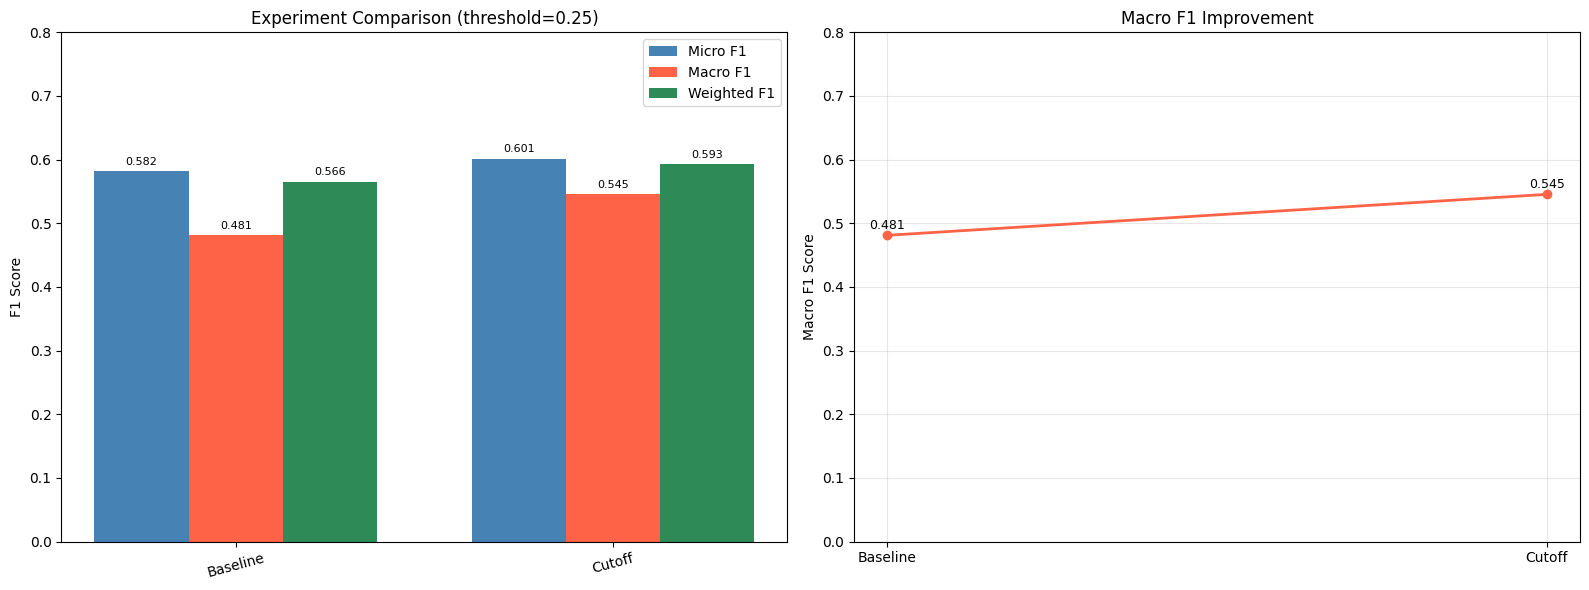

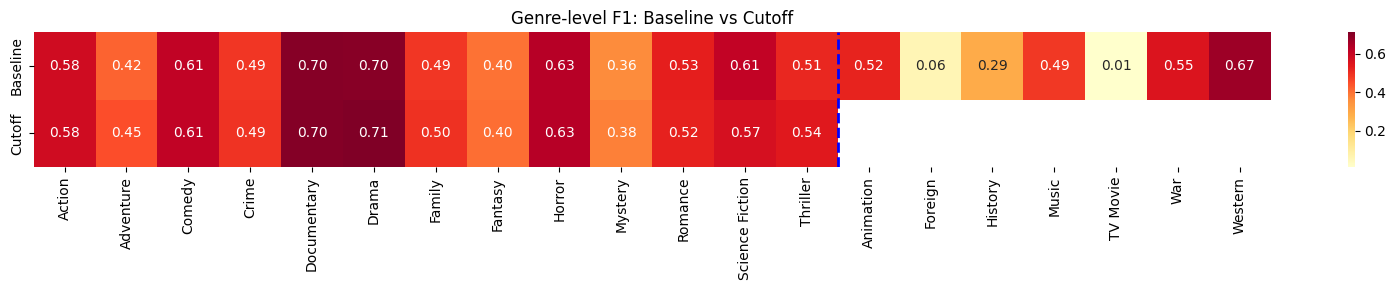

In [ ]:
# ── Visualization ──────────────────────────────────────────
experiments = list(results.keys())
micro_scores  = [results[e]['micro']    for e in experiments]
macro_scores  = [results[e]['macro']    for e in experiments]
weighted_scores = [results[e]['weighted'] for e in experiments]

x = np.arange(len(experiments))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ① Performance Comparison bar chart
ax = axes[0]
ax.bar(x - width, micro_scores,   width, label='Micro F1',    color='steelblue')
ax.bar(x,          macro_scores,   width, label='Macro F1',    color='tomato')
ax.bar(x + width,  weighted_scores,width, label='Weighted F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=15)
ax.set_ylim(0, 0.8)
ax.set_ylabel('F1 Score')
ax.set_title('Experiment Comparison (threshold=0.25)')
ax.legend()
for i, (mi, ma, we) in enumerate(zip(micro_scores, macro_scores, weighted_scores)):
    ax.text(i - width, mi + 0.01, f'{mi:.3f}', ha='center', fontsize=8)
    ax.text(i,         ma + 0.01, f'{ma:.3f}', ha='center', fontsize=8)
    ax.text(i + width, we + 0.01, f'{we:.3f}', ha='center', fontsize=8)

# ② Macro F1 Performance Line Chart
ax2 = axes[1]
ax2.plot(experiments, macro_scores, marker='o', color='tomato', linewidth=2)
ax2.set_ylim(0, 0.8)
ax2.set_ylabel('Macro F1 Score')
ax2.set_title('Macro F1 Improvement')
ax2.grid(True, alpha=0.3)
for i, v in enumerate(macro_scores):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ③ F1 Hitmap (Baseline vs Best)
# cutoff vs baseline genres
kept_genres = [g for g in genre_cols if movies[g].sum() > 2000]
cut_genres  = [g for g in genre_cols if movies[g].sum() <= 2000]

# order: kept first, cut last
ordered_genres = kept_genres + cut_genres

# Baseline per_genre is in genre_cols order
base_f1_dict = dict(zip(genre_cols, results['Baseline']['per_genre']))
cut_f1_dict  = dict(zip(valid_genres, results['Cutoff']['per_genre']))

# Hitmap data
baseline_row = [base_f1_dict[g] for g in ordered_genres]
cutoff_row   = [cut_f1_dict.get(g, None) for g in ordered_genres]  # cut genres will shown None

genre_df = pd.DataFrame(
    [baseline_row, cutoff_row],
    index=['Baseline', 'Cutoff'],
    columns=ordered_genres
)

# separator location
split_idx = len(kept_genres)

fig, ax = plt.subplots(figsize=(16, 3))
sns.heatmap(genre_df, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, mask=genre_df.isnull())

# separator
ax.axvline(x=split_idx, color='blue', linewidth=2, linestyle='--')

ax.set_title('Genre-level F1: Baseline vs Cutoff')
plt.tight_layout()
plt.show()

In [ ]:
thresholds = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7]

print("=== Baseline ===")
for t in thresholds:
    y_pred_t = (y_probs_base >= t).astype(int)
    micro = f1_score(y_test, y_pred_t, average="micro")
    macro = f1_score(y_test, y_pred_t, average="macro")
    print(f"Threshold: {t:.2f} | Micro F1: {micro:.4f} | Macro F1: {macro:.4f}")

print("\n=== Cutoff ===")
for t in thresholds:
    y_pred_t = (y_probs_cut >= t).astype(int)
    micro = f1_score(y_test_c, y_pred_t, average="micro")
    macro = f1_score(y_test_c, y_pred_t, average="macro")
    print(f"Threshold: {t:.2f} | Micro F1: {micro:.4f} | Macro F1: {macro:.4f}")

=== Baseline ===
Threshold: 0.10 | Micro F1: 0.5084 | Macro F1: 0.4389
Threshold: 0.20 | Micro F1: 0.5761 | Macro F1: 0.4867
Threshold: 0.25 | Micro F1: 0.5870 | Macro F1: 0.4853
Threshold: 0.30 | Micro F1: 0.5858 | Macro F1: 0.4760
Threshold: 0.35 | Micro F1: 0.5785 | Macro F1: 0.4605
Threshold: 0.40 | Micro F1: 0.5624 | Macro F1: 0.4399
Threshold: 0.50 | Micro F1: 0.5121 | Macro F1: 0.3861
Threshold: 0.60 | Micro F1: 0.4333 | Macro F1: 0.3192
Threshold: 0.70 | Micro F1: 0.3249 | Macro F1: 0.2414

=== Cutoff ===
Threshold: 0.10 | Micro F1: 0.5200 | Macro F1: 0.4800
Threshold: 0.20 | Micro F1: 0.5899 | Macro F1: 0.5415
Threshold: 0.25 | Micro F1: 0.6014 | Macro F1: 0.5454
Threshold: 0.30 | Micro F1: 0.6013 | Macro F1: 0.5356
Threshold: 0.35 | Micro F1: 0.5940 | Macro F1: 0.5192
Threshold: 0.40 | Micro F1: 0.5822 | Macro F1: 0.4980
Threshold: 0.50 | Micro F1: 0.5314 | Macro F1: 0.4371
Threshold: 0.60 | Micro F1: 0.4485 | Macro F1: 0.3583
Threshold: 0.70 | Micro F1: 0.3395 | Macro F1: 0.

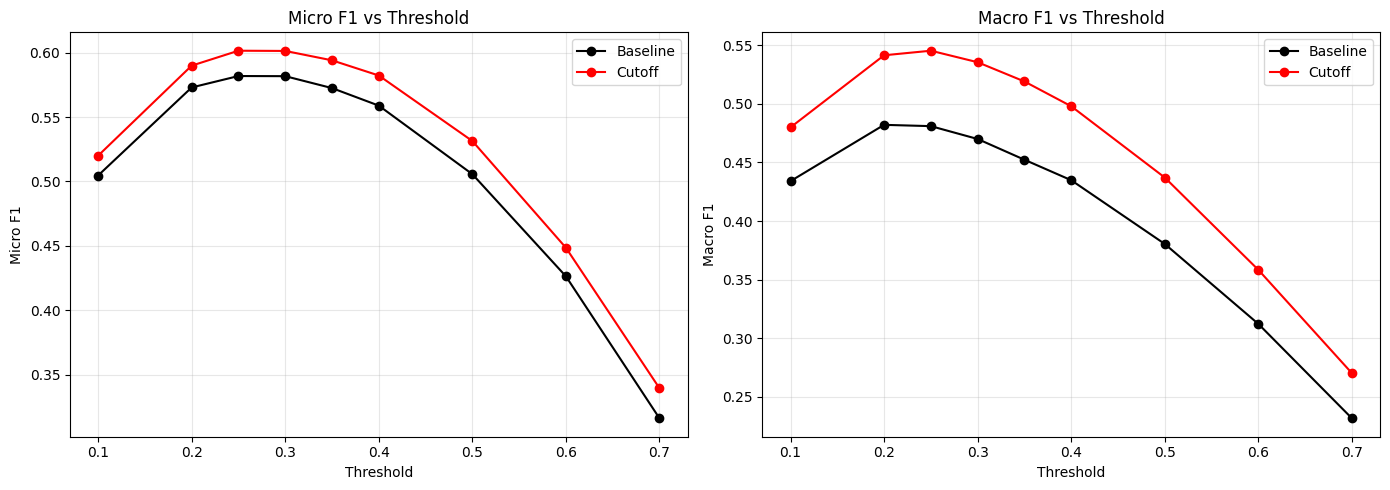

In [ ]:
thresholds = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7]

base_micro, base_macro = [], []
cut_micro, cut_macro = [], []

for t in thresholds:
    y_pred_t = (y_probs_base >= t).astype(int)
    base_micro.append(f1_score(y_test, y_pred_t, average="micro"))
    base_macro.append(f1_score(y_test, y_pred_t, average="macro"))

for t in thresholds:
    y_pred_t = (y_probs_cut >= t).astype(int)
    cut_micro.append(f1_score(y_test_c, y_pred_t, average="micro"))
    cut_macro.append(f1_score(y_test_c, y_pred_t, average="macro"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Micro F1
axes[0].plot(thresholds, base_micro, color='black', marker='o', label='Baseline')
axes[0].plot(thresholds, cut_micro,  color='red',   marker='o', label='Cutoff')
axes[0].set_title('Micro F1 vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Micro F1')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Macro F1
axes[1].plot(thresholds, base_macro, color='black', marker='o', label='Baseline')
axes[1].plot(thresholds, cut_macro,  color='red',   marker='o', label='Cutoff')
axes[1].set_title('Macro F1 vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Macro F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

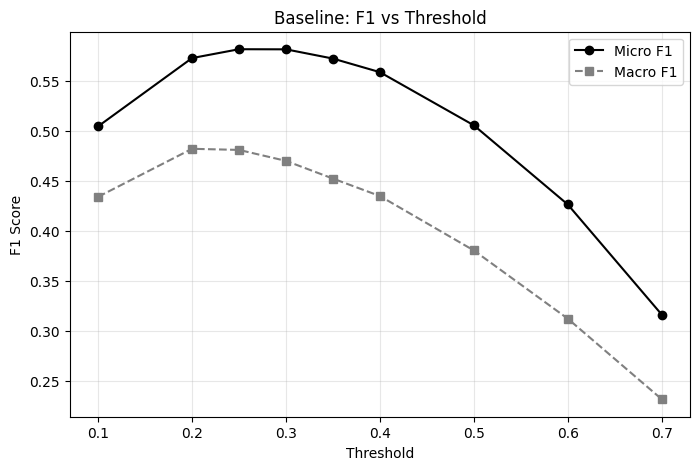

In [ ]:
thresholds = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7]

base_micro, base_macro = [], []

for t in thresholds:
    y_pred_t = (y_probs_base >= t).astype(int)
    base_micro.append(f1_score(y_test, y_pred_t, average="micro"))
    base_macro.append(f1_score(y_test, y_pred_t, average="macro"))

plt.figure(figsize=(8, 5))
plt.plot(thresholds, base_micro, color='black', marker='o', label='Micro F1')
plt.plot(thresholds, base_macro, color='gray',  marker='s', linestyle='--', label='Macro F1')
plt.title('Baseline: F1 vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**XG Boost(no balance, just cut off)**

In [ ]:
from xgboost import XGBClassifier
from tqdm import tqdm
import numpy as np
X_cut = embeddings[has_genre]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

n_genres = y_train_c.shape[1]
genre_names = valid_genres  # 13개 장르 이름

# OvR 수동으로 돌리기 (tqdm 적용)
models_xgb = []
y_probs_list = []

for i in tqdm(range(n_genres), desc="Training XGBoost"):
    clf = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1,
        eval_metric='logloss',
        verbosity=0
    )
    clf.fit(X_train_c, y_train_c[:, i])
    models_xgb.append(clf)
    y_probs_list.append(clf.predict_proba(X_test_c)[:, 1])
    tqdm.write(f"  ✓ {genre_names[i]}")

y_probs_xgb = np.column_stack(y_probs_list)
y_pred_xgb = (y_probs_xgb >= 0.25).astype(int)

results['XGBoost'] = {
    'micro': f1_score(y_test_c, y_pred_xgb, average='micro'),
    'macro': f1_score(y_test_c, y_pred_xgb, average='macro'),
    'weighted': f1_score(y_test_c, y_pred_xgb, average='weighted'),
    'per_genre': f1_score(y_test_c, y_pred_xgb, average=None)
}
print("\nXGBoost Complete")
print(f"Micro: {results['XGBoost']['micro']:.4f} | Macro: {results['XGBoost']['macro']:.4f}")

Training XGBoost:   8%|▊         | 1/13 [01:00<12:09, 60.79s/it]

  ✓ Action


Training XGBoost:  15%|█▌        | 2/13 [01:55<10:27, 57.01s/it]

  ✓ Adventure


Training XGBoost:  23%|██▎       | 3/13 [02:58<09:59, 59.99s/it]

...

  ✓ Romance


Training XGBoost:  92%|█████████▏| 12/13 [11:20<00:54, 54.73s/it]

  ✓ Science Fiction


Training XGBoost: 100%|██████████| 13/13 [12:17<00:00, 56.75s/it]

  ✓ Thriller

XGBoost Complete
Micro: 0.5965 | Macro: 0.5278


In [ ]:
thresholds = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.6, 0.7]

best_micro, best_macro, best_threshold = 0, 0, 0

for t in thresholds:
    y_pred_t = (y_probs_xgb >= t).astype(int)
    micro = f1_score(y_test_c, y_pred_t, average='micro')
    macro = f1_score(y_test_c, y_pred_t, average='macro')
    print(f"threshold={t:.2f} | Micro: {micro:.4f} | Macro: {macro:.4f}")

    if micro > best_micro:
        best_micro = micro
        best_macro = macro
        best_threshold = t

print(f"\n✓ Best threshold: {best_threshold} | Micro: {best_micro:.4f} | Macro: {best_macro:.4f}")

threshold=0.10 | Micro: 0.5424 | Macro: 0.5065
threshold=0.20 | Micro: 0.5896 | Macro: 0.5322
threshold=0.25 | Micro: 0.5965 | Macro: 0.5278
threshold=0.30 | Micro: 0.5903 | Macro: 0.5082
threshold=0.35 | Micro: 0.5804 | Macro: 0.4876
threshold=0.40 | Micro: 0.5627 | Macro: 0.4620
threshold=0.50 | Micro: 0.5042 | Macro: 0.3992
threshold=0.60 | Micro: 0.4203 | Macro: 0.3233
threshold=0.70 | Micro: 0.3116 | Macro: 0.2414

✓ Best threshold: 0.25 | Micro: 0.5965 | Macro: 0.5278


**XGBoost(weight rebalanced)**

In [ ]:
from tqdm import tqdm
import numpy as np

X_cut = embeddings[has_genre]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

n_genres = y_train_c.shape[1]
genre_names = valid_genres

y_probs_list = []

for i in tqdm(range(n_genres), desc="Training LogReg (balanced)"):
    clf = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # 추가
        solver='saga',
        n_jobs=-1
    )
    clf.fit(X_train_c, y_train_c[:, i])
    y_probs_list.append(clf.predict_proba(X_test_c)[:, 1])
    tqdm.write(f"  ✓ {genre_names[i]}")

y_probs_bal = np.column_stack(y_probs_list)
y_pred_bal = (y_probs_bal >= 0.25).astype(int)

results['Balanced'] = {
    'micro': f1_score(y_test_c, y_pred_bal, average='micro'),
    'macro': f1_score(y_test_c, y_pred_bal, average='macro'),
    'weighted': f1_score(y_test_c, y_pred_bal, average='weighted'),
    'per_genre': f1_score(y_test_c, y_pred_bal, average=None)
}
print("\nBalanced Complete")
print(f"Micro: {results['Balanced']['micro']:.4f} | Macro: {results['Balanced']['macro']:.4f}")

Training LogReg (balanced):   8%|▊         | 1/13 [00:11<02:12, 11.04s/it]

  ✓ Action


Training LogReg (balanced):  15%|█▌        | 2/13 [00:49<04:58, 27.09s/it]

  ✓ Adventure


Training LogReg (balanced):  23%|██▎       | 3/13 [00:56<02:58, 17.84s/it]

...

  ✓ Romance


Training LogReg (balanced):  92%|█████████▏| 12/13 [15:47<01:31, 91.40s/it] 

  ✓ Science Fiction


Training LogReg (balanced): 100%|██████████| 13/13 [15:55<00:00, 73.49s/it]

  ✓ Thriller

Balanced Complete
Micro: 0.4415 | Macro: 0.3984


**LightGBM(No balance, No adding features, just cutoff)**

In [ ]:
from lightgbm import LGBMClassifier
from tqdm import tqdm
import numpy as np

X_cut = embeddings[has_genre]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

n_genres = y_train_c.shape[1]
genre_names = valid_genres

models_lgbm = []
y_probs_list = []

for i in tqdm(range(n_genres), desc="Training LightGBM"):
    clf = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1,
        verbosity=-1
    )
    clf.fit(X_train_c, y_train_c[:, i])
    models_lgbm.append(clf)
    y_probs_list.append(clf.predict_proba(X_test_c)[:, 1])
    tqdm.write(f"  ✓ {genre_names[i]}")

y_probs_lgbm = np.column_stack(y_probs_list)
y_pred_lgbm = (y_probs_lgbm >= 0.25).astype(int)

results['LightGBM'] = {
    'micro': f1_score(y_test_c, y_pred_lgbm, average='micro'),
    'macro': f1_score(y_test_c, y_pred_lgbm, average='macro'),
    'weighted': f1_score(y_test_c, y_pred_lgbm, average='weighted'),
    'per_genre': f1_score(y_test_c, y_pred_lgbm, average=None)
}
print("\nLightGBM Complete")
print(f"Micro: {results['LightGBM']['micro']:.4f} | Macro: {results['LightGBM']['macro']:.4f}")

Training LightGBM:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Training LightGBM:   8%|▊         | 1/13 [00:28<05:43, 28.60s/it]

  ✓ Action


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Training LightGBM:  15%|█▌        | 2/13 [00:55<05:00, 27.34s/it]

  ✓ Adventure


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Training LightGBM:  23%|██▎       | 3/13 [01:23<04:39, 27.96s/it]

...

  ✓ Romance


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Training LightGBM:  92%|█████████▏| 12/13 [06:11<00:30, 30.58s/it]

  ✓ Science Fiction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Training LightGBM: 100%|██████████| 13/13 [06:39<00:00, 30.73s/it]

  ✓ Thriller

LightGBM Complete
Micro: 0.5929 | Macro: 0.5252


In [ ]:
from tqdm import tqdm
import numpy as np

X_cut = embeddings[has_genre]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cut, y_cut, test_size=0.2, random_state=42
)

n_genres = y_train_c.shape[1]
genre_names = valid_genres

y_probs_list = []

for i in tqdm(range(n_genres), desc="Training LogReg (balanced)"):
    clf = LogisticRegression(
        max_iter=1000,
        class_weight='balanced',  # 추가
        solver='saga',
        n_jobs=-1
    )
    clf.fit(X_train_c, y_train_c[:, i])
    y_probs_list.append(clf.predict_proba(X_test_c)[:, 1])
    tqdm.write(f"  ✓ {genre_names[i]}")

y_probs_bal = np.column_stack(y_probs_list)
y_pred_bal = (y_probs_bal >= 0.25).astype(int)

results['Balanced'] = {
    'micro': f1_score(y_test_c, y_pred_bal, average='micro'),
    'macro': f1_score(y_test_c, y_pred_bal, average='macro'),
    'weighted': f1_score(y_test_c, y_pred_bal, average='weighted'),
    'per_genre': f1_score(y_test_c, y_pred_bal, average=None)
}
print("\nBalanced Complete")
print(f"Micro: {results['Balanced']['micro']:.4f} | Macro: {results['Balanced']['macro']:.4f}")

Training LogReg (balanced):   0%|          | 0/13 [00:12<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
from lightgbm import LGBMClassifier
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_st = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

# Define 4 text combinations
text_combinations = {
    'overview': movies['overview'].fillna(''),
    'title+overview': movies['original_title'].fillna('') + ' ' + movies['overview'].fillna(''),
    'tagline+overview': movies['tagline'].fillna('') + ' ' + movies['overview'].fillna(''),
    'title+tagline+overview': movies['original_title'].fillna('') + ' ' + movies['tagline'].fillna('') + ' ' + movies['overview'].fillna('')
}

def run_lgbm(embeddings, y_cut, has_genre, genre_names, label):
    X = embeddings[has_genre]
    y = y_cut

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    y_probs_list = []
    for i in tqdm(range(y_train.shape[1]), desc=f"LightGBM [{label}]", position=1, leave=False):
        clf = LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            n_jobs=-1,
            verbosity=-1
        )
        clf.fit(X_train, y_train[:, i])
        y_probs_list.append(clf.predict_proba(X_test)[:, 1])
        tqdm.write(f"  ✓ {genre_names[i]}")

    y_probs = np.column_stack(y_probs_list)
    y_pred = (y_probs >= 0.25).astype(int)

    return {
        'micro': f1_score(y_test, y_pred, average='micro'),
        'macro': f1_score(y_test, y_pred, average='macro'),
        'weighted': f1_score(y_test, y_pred, average='weighted'),
        'per_genre': f1_score(y_test, y_pred, average=None)
    }

# Run experiments for each text combination
for label, texts in tqdm(text_combinations.items(), desc="Text Combinations", position=0):
    print(f"\n{'='*50}")
    print(f"Encoding: {label}")
    emb = model_st.encode(texts.tolist(), show_progress_bar=True, device=device)
    emb = np.asarray(emb)

    results[f'LightGBM_{label}'] = run_lgbm(emb, y_cut, has_genre, valid_genres, label)
    print(f"Micro: {results[f'LightGBM_{label}']['micro']:.4f} | Macro: {results[f'LightGBM_{label}']['macro']:.4f}")

# Final comparison by Macro F1
print("\n" + "="*50)
print("Final Comparison (Macro F1)")
print("="*50)
for key in [k for k in results if k.startswith('LightGBM')]:
    print(f"{key:35s} | Macro: {results[key]['macro']:.4f} | Micro: {results[key]['micro']:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Text Combinations:   0%|          | 0/4 [00:00<?, ?it/s]


Encoding: overview


Batches:   0%|          | 0/1323 [00:00<?, ?it/s]


LightGBM [overview]:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(

LightGBM [overview]:   8%|▊         | 1/13 [00:26<05:20, 26.72s/it]

...

  ✓ Crime


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(

LightGBM [overview]:  38%|███▊      | 5/13 [02:18<03:45, 28.19s/it]

  ✓ Documentary



Text Combinations:   0%|          | 0/4 [03:19<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_st = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

# Define 4 text combinations
text_combinations = {
    'overview': movies['overview'].fillna(''),
    'title+overview': movies['original_title'].fillna('') + ' ' + movies['overview'].fillna(''),
    'tagline+overview': movies['tagline'].fillna('') + ' ' + movies['overview'].fillna(''),
    'title+tagline+overview': movies['original_title'].fillna('') + ' ' + movies['tagline'].fillna('') + ' ' + movies['overview'].fillna('')
}

def run_logreg(embeddings, y_cut, has_genre, genre_names, label):
    X = embeddings[has_genre]
    y = y_cut

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    y_probs_list = []
    for i in tqdm(range(y_train.shape[1]), desc=f"LogReg [{label}]", position=1, leave=False):
        clf = LogisticRegression(
            max_iter=1000,
            solver='saga',
            n_jobs=-1
        )
        clf.fit(X_train, y_train[:, i])
        y_probs_list.append(clf.predict_proba(X_test)[:, 1])
        tqdm.write(f"  ✓ {genre_names[i]}")

    y_probs = np.column_stack(y_probs_list)
    y_pred = (y_probs >= 0.25).astype(int)

    return {
        'micro': f1_score(y_test, y_pred, average='micro'),
        'macro': f1_score(y_test, y_pred, average='macro'),
        'weighted': f1_score(y_test, y_pred, average='weighted'),
        'per_genre': f1_score(y_test, y_pred, average=None)
    }

# Run experiments for each text combination
for label, texts in tqdm(text_combinations.items(), desc="Text Combinations", position=0):
    print(f"\n{'='*50}")
    print(f"Encoding: {label}")
    emb = model_st.encode(texts.tolist(), show_progress_bar=True, device=device)
    emb = np.asarray(emb)

    results[f'LogReg_{label}'] = run_logreg(emb, y_cut, has_genre, valid_genres, label)
    print(f"Micro: {results[f'LogReg_{label}']['micro']:.4f} | Macro: {results[f'LogReg_{label}']['macro']:.4f}")

# Final comparison by Macro F1
print("\n" + "="*50)
print("Final Comparison (Macro F1)")
print("="*50)
for key in [k for k in results if k.startswith('LogReg')]:
    print(f"{key:35s} | Macro: {results[key]['macro']:.4f} | Micro: {results[key]['micro']:.4f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Text Combinations:   0%|          | 0/4 [00:00<?, ?it/s]


Encoding: overview


Batches:   0%|          | 0/1323 [00:00<?, ?it/s]


LogReg [overview]:   0%|          | 0/13 [00:00<?, ?it/s]

LogReg [overview]:   8%|▊         | 1/13 [00:06<01:12,  6.08s/it]

...

  ✓ Romance




LogReg [title+tagline+overview]:  92%|█████████▏| 12/13 [01:05<00:05,  5.55s/it]

  ✓ Science Fiction




Text Combinations: 100%|██████████| 4/4 [07:56<00:00, 119.19s/it]

  ✓ Thriller
Micro: 0.6098 | Macro: 0.5559

Final Comparison (Macro F1)
LogReg_overview                     | Macro: 0.5463 | Micro: 0.6018
LogReg_title+overview               | Macro: 0.5473 | Micro: 0.6023
LogReg_tagline+overview             | Macro: 0.5528 | Micro: 0.6077
LogReg_title+tagline+overview       | Macro: 0.5559 | Micro: 0.6098
